# Data Preprocessing: Converting Quarterly Prices into Monthly Prices Using Linear Interpolation

In this notebook I focus on restructuring the *Median House Price* dataset.
The original data set contained quarterly data, which I deemed insufficient in building a time series model, according to the tutorials I have been following.

To improve the model’s ability to capture short-term trends and provide more accurate forecasts, I convert the data to a monthly frequency using linear interpolation.

The dataset used in this analysis was obtained from the UK Office for National Statistics (ONS):
**Median House Prices by Middle Layer Super Output Area (MSOA)**
Available at: [ONS Dataset](https://www.ons.gov.uk/peoplepopulationandcommunity/housing/datasets/medianhousepricesbymiddlelayersuperoutputarea)

## Importing Libraries and File Handling
In this section I import the neccesary libraries and set the file path. Here I also clean the data in order to prevent bugs in future executions.

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

#Load the CSV file
df = pd.read_csv("interim/median_sale.csv")

#Show the first few rows
df.head()

,Region code,Region,Local authority code,LocalAuthority,01/12/1995,01/03/1996,01/06/1996,01/09/1996,01/12/1996,01/03/1997,...,01/12/2021,01/03/2022,01/06/2022,01/09/2022,01/12/2022,01/03/2023,01/06/2023,01/09/2023,01/12/2023,01/03/2024
0,E92000001,England,eng,England,55000.00,55000.00,55500.00,56500.00,57500.00,58000.00,...,281000.00,275000.00,269995.00,285000.00,295000.00,297995.00,299950.00,295000.00,290000.00,287500.00
1,E12000001,North East,E06000001,Hartlepool,38322.73,37895.45,37631.82,37394.32,38384.09,38404.45,...,124354.45,122331.45,121702.27,123181.18,127590.91,130174.50,131172.50,134679.45,129572.45,128565.86
2,E12000001,North East,E06000002,Middlesbrough,41160.26,41156.18,41170.39,41398.16,41327.89,41604.16,...,128894.29,129336.21,133555.47,135224.87,135906.29,138123.71,135444.18,135090.34,134933.95,134500.00
3,E12000001,North East,E06000003,Redcar and Cleveland,42087.37,42453.95,42801.32,41757.89,41970.13,42003.29,...,142118.21,142304.97,145733.68,148281.58,152316.79,153683.87,153984.47,153406.58,151381.58,151486.74
4,E12000001,North East,E06000004,Stockton-on-Tees,44559.83,44250.44,44372.94,44240.96,44880.44,44885.00,...,154223.90,153290.29,156716.87,160520.75,167725.65,170726.04,167982.63,169043.98,166456.15,163018.29


## Reshaping and Cleaning Dataset
In this section I transform the dataset from wide to long format

In [2]:
#Removing any white space
df.columns = df.columns.str.strip()

#Defining date columns
date_columns = df.columns.difference(['Region code', 'Region', 'Local authority code', 'LocalAuthority'])

#Each date column is converted into a row while id variables remain as columns
prices_df = df.melt(
    id_vars= ['Region code', 'Region', 'Local authority code', 'LocalAuthority'],
    value_vars= date_columns,
    var_name="Date",
    value_name="Price"
)

#Convert date column into datetime object
prices_df["Date"] = pd.to_datetime(prices_df["Date"], format="%d/%m/%Y")

In [3]:
prices_df

,Region code,Region,Local authority code,LocalAuthority,Date,Price
0,E92000001,England,eng,England,1996-03-01,55000.00
1,E12000001,North East,E06000001,Hartlepool,1996-03-01,37895.45
2,E12000001,North East,E06000002,Middlesbrough,1996-03-01,41156.18
3,E12000001,North East,E06000003,Redcar and Cleveland,1996-03-01,42453.95
4,E12000001,North East,E06000004,Stockton-on-Tees,1996-03-01,44250.44
...,...,...,...,...,...,...
33853,E12000009,South West,E07000079,Cotswold,2023-12-01,471136.36
33854,E12000009,South West,E07000080,Forest Dean,2023-12-01,304022.25
33855,E12000009,South West,E07000081,Gloucester,2023-12-01,245315.00
33856,E12000009,South West,E07000082,Stroud,2023-12-01,362183.33


# Creating the Monthly Date Range

In [4]:
#Creating timestamp object for start and end date
start_date = pd.Timestamp("1995-12-01")
end_date = pd.Timestamp("2024-03-01")

#Generating monthly dates from start to end date
date_range = pd.date_range(start=start_date, end=end_date, freq="MS")

#Saving to data frame
date_df = pd.DataFrame({"Date": date_range})

In [5]:
date_df

,Date
0,1995-12-01
1,1996-01-01
2,1996-02-01
3,1996-03-01
4,1996-04-01
...,...
335,2023-11-01
336,2023-12-01
337,2024-01-01
338,2024-02-01


Here, I am creating a separate DataFrame to hold the local authority codes. This will act as a primary key when combining the full set of monthly dates with the original dataset. 

In [6]:
auth_df = pd.DataFrame({"Local authority code": prices_df["Local authority code"].unique()})
auth_df["Local authority code"] = auth_df["Local authority code"].astype(str).str.strip()

In [7]:
#Creating a dataframe combining all local authority codes with every monthly date. 
full_index = auth_df.merge(date_df, how="cross")

In [8]:
full_index

,Local authority code,Date
0,eng,1995-12-01
1,eng,1996-01-01
2,eng,1996-02-01
3,eng,1996-03-01
4,eng,1996-04-01
...,...,...
100975,E07000083,2023-11-01
100976,E07000083,2023-12-01
100977,E07000083,2024-01-01
100978,E07000083,2024-02-01


In [9]:
#Ensuring both data frames are in the correct datetime format
full_index["Date"] = pd.to_datetime(full_index["Date"])
prices_df["Date"] = pd.to_datetime(prices_df["Date"])

## Merging Date Data with Location Data

In [10]:
#Merging the original dataset with time series data
merged_df = full_index.merge(prices_df, on=["Local authority code", "Date"], how="left")
merged_df

,Local authority code,Date,Region code,Region,LocalAuthority,Price
0,eng,1995-12-01,E92000001,England,England,55000.0
1,eng,1996-01-01,NaN,NaN,NaN,NaN
2,eng,1996-02-01,NaN,NaN,NaN,NaN
3,eng,1996-03-01,E92000001,England,England,55000.0
4,eng,1996-04-01,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
100975,E07000083,2023-11-01,NaN,NaN,NaN,NaN
100976,E07000083,2023-12-01,E12000009,South West,Tewkesbury,352199.5
100977,E07000083,2024-01-01,NaN,NaN,NaN,NaN
100978,E07000083,2024-02-01,NaN,NaN,NaN,NaN


In [11]:
#Filling in missing monthly prices using linear interpolation. 
#Data is grouped by local authority code so data is interpolated within each authority 
merged_df["Price"] = merged_df.groupby("Local authority code")["Price"].transform(
    lambda x: x.interpolate(method="linear", ).round(2))

In [12]:
merged_df

,Local authority code,Date,Region code,Region,LocalAuthority,Price
0,eng,1995-12-01,E92000001,England,England,55000.00
1,eng,1996-01-01,NaN,NaN,NaN,55000.00
2,eng,1996-02-01,NaN,NaN,NaN,55000.00
3,eng,1996-03-01,E92000001,England,England,55000.00
4,eng,1996-04-01,NaN,NaN,NaN,55166.67
...,...,...,...,...,...,...
100975,E07000083,2023-11-01,NaN,NaN,NaN,352141.00
100976,E07000083,2023-12-01,E12000009,South West,Tewkesbury,352199.50
100977,E07000083,2024-01-01,NaN,NaN,NaN,350149.67
100978,E07000083,2024-02-01,NaN,NaN,NaN,348099.83


In [13]:
#Applying forward-fill to fill in missing Region and Local Authority values
merged_df[["Region code", "Region", "LocalAuthority"]] = (
    merged_df.groupby("Local authority code")[["Region code", "Region", "LocalAuthority"]]
    .ffill()
)

In [14]:
merged_df

,Local authority code,Date,Region code,Region,LocalAuthority,Price
0,eng,1995-12-01,E92000001,England,England,55000.00
1,eng,1996-01-01,E92000001,England,England,55000.00
2,eng,1996-02-01,E92000001,England,England,55000.00
3,eng,1996-03-01,E92000001,England,England,55000.00
4,eng,1996-04-01,E92000001,England,England,55166.67
...,...,...,...,...,...,...
100975,E07000083,2023-11-01,E12000009,South West,Tewkesbury,352141.00
100976,E07000083,2023-12-01,E12000009,South West,Tewkesbury,352199.50
100977,E07000083,2024-01-01,E12000009,South West,Tewkesbury,350149.67
100978,E07000083,2024-02-01,E12000009,South West,Tewkesbury,348099.83


## Saving Final Dataset

In [15]:
merged_df.to_csv("interim/monthly_median_prices.csv", index=False)

## Plotting House Prices Against Regions

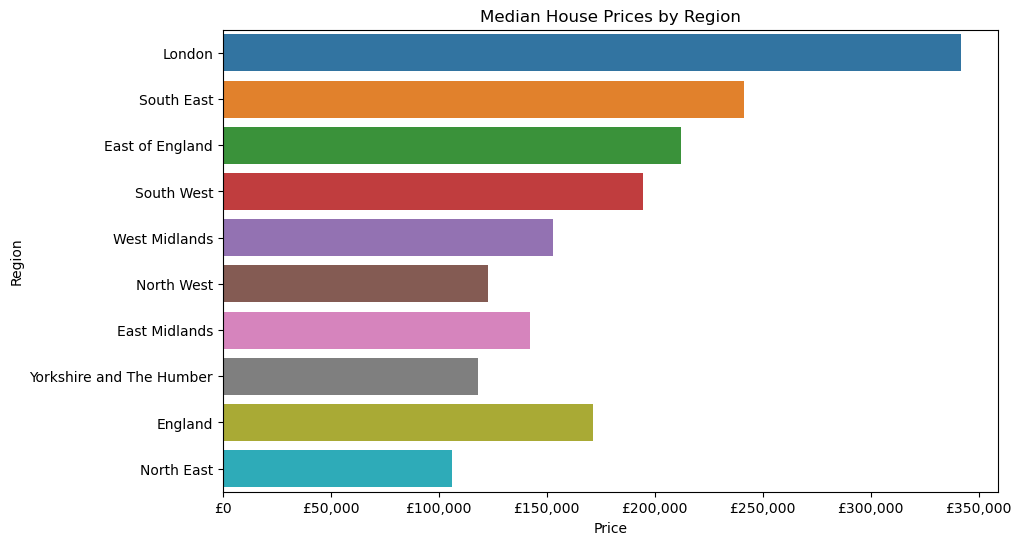

In [25]:
plt.figure(figsize=(10,6))
#Plotting house prices against regions
sns.barplot(data=merged_df.sort_values('Price', ascending=False),
            x='Price',
            y='Region',
            errorbar=None,
            hue='Region',
            legend = False)
plt.title("Median House Prices by Region")
plt.xlabel("Price")
plt.ylabel("Region")

#Format price with £
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))

plt.show()
